# Chapter 39 Lab — Training and Testing Predictive Models (Python)

This lab makes the central lessons of Chapter 39 concrete with three simulation experiments where **we know the truth**, so every bias is visible:

1. **Nested vs. non-nested cross-validation** — how choosing hyperparameters and scoring the model on the same folds inflates accuracy.
2. **Subject-level leakage** — how randomly splitting *images* instead of *subjects* produces impressive accuracy from pure noise, and how grouped folds fix it.
3. **Effect-size shrinkage** — how apparent performance shrinks from the training sample, to cross-validation, to an independent test cohort, and why Pearson's *r* can hide a badly miscalibrated model.

**How to run this notebook:** it runs directly in your browser on the tutorial site, in [Google Colab](https://colab.research.google.com/), or locally — it uses only numpy, pandas, scikit-learn, scipy, and matplotlib (no downloads, all data simulated). See the [chapter page](../ch39-training-and-testing-predictive-models.md) for the concepts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.svm import SVC
from sklearn.linear_model import Ridge
from sklearn.model_selection import (KFold, GroupKFold, GridSearchCV,
                                     cross_val_score, cross_val_predict)

jitter_rng = np.random.default_rng(0)   # only for plot jitter
np.set_printoptions(precision=3, suppress=True)

## Part 1 — Nested vs. non-nested cross-validation

Hyperparameters (an SVM's `C` and `gamma`, a penalty strength, a number of components) must be *chosen* somehow. A tempting shortcut is: run cross-validation for every setting on the whole dataset, then report the best score. But the winning score was **selected** — it is the maximum of many noisy estimates, and the same folds that picked the winner also scored it. That is hidden model flexibility.

**Nested cross-validation** separates the two jobs:
- an **inner loop**, run within each training set, compares hyperparameter settings and picks a winner;
- an **outer loop** evaluates the *entire selection procedure* on folds it has never touched.

To expose the bias we use **pure-noise data**: features and labels are independent, so the true accuracy of *any* classifier is exactly 50%. An honest procedure should say so.

In [2]:
rng = np.random.default_rng(7)
n, p = 40, 50                       # small n, many features: fertile ground for overfitting
n_repeats = 15
grid = {"C": [0.1, 1, 10, 100], "gamma": [1e-3, 1e-2, 1e-1, 1]}

non_nested, nested = [], []
for rep in range(n_repeats):
    X = rng.standard_normal((n, p))
    y = rng.integers(0, 2, n)       # labels are pure noise: true accuracy = 0.5

    inner = GridSearchCV(SVC(kernel="rbf"), grid, cv=3, n_jobs=1)

    # NON-NESTED: the same folds pick the hyperparameters AND score the model
    non_nested.append(inner.fit(X, y).best_score_)

    # NESTED: an outer 5-fold loop scores the whole selection procedure
    nested.append(cross_val_score(inner, X, y, cv=5, n_jobs=1).mean())

non_nested, nested = np.array(non_nested), np.array(nested)
print(f"True accuracy of any model on these data:  0.500")
print(f"Non-nested (biased) estimate:   mean = {non_nested.mean():.3f}")
print(f"Nested (honest) estimate:       mean = {nested.mean():.3f}")
print(f"Average optimism from selection: {non_nested.mean() - nested.mean():+.3f}")

True accuracy of any model on these data:  0.500
Non-nested (biased) estimate:   mean = 0.602
Nested (honest) estimate:       mean = 0.517
Average optimism from selection: +0.085


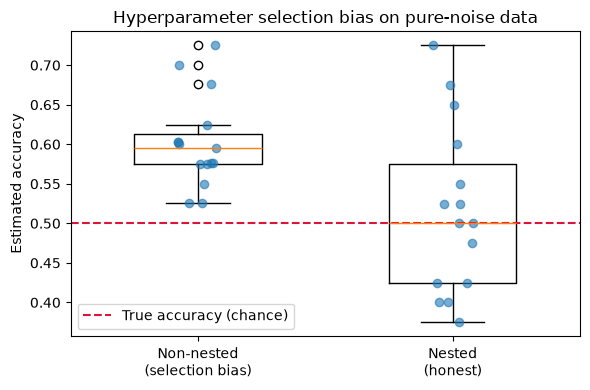

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([non_nested, nested], tick_labels=["Non-nested\n(selection bias)", "Nested\n(honest)"],
           widths=0.5)
for i, vals in enumerate([non_nested, nested], start=1):
    ax.plot(np.full_like(vals, i) + jitter_rng.uniform(-0.08, 0.08, vals.size), vals,
            "o", alpha=0.6, color="tab:blue")
ax.axhline(0.5, color="crimson", ls="--", label="True accuracy (chance)")
ax.set_ylabel("Estimated accuracy")
ax.set_title("Hyperparameter selection bias on pure-noise data")
ax.legend()
plt.tight_layout()
plt.show()

The non-nested estimates sit systematically **above chance** even though there is nothing to find — the gap is pure selection bias, and it grows with the size of the hyperparameter grid and shrinks with sample size. The nested estimates scatter around 0.50, as they should. The same logic applies to *any* choice made using the whole dataset: feature selection, preprocessing options, algorithm shoot-outs. **Every operation belongs inside the cross-validation loop.**

## Part 2 — Subject-level leakage: random splits vs. grouped splits

fMRI datasets almost always contain **multiple images per person** — trials, conditions, runs, sessions. Images from the same person share stable idiosyncratic structure (anatomy, vasculature, scanner session — a "fingerprint"), so their errors are *not* independent.

We simulate 30 subjects × 8 images. Each subject gets a random fingerprint pattern that appears in all of their images. The label is assigned **per subject, completely at random** — brain data carry zero information about it. Honest accuracy: 50%.

Then we cross-validate two ways:
- **Random 5-fold split of images** (`KFold`) — a given subject's images land in both training and test sets.
- **Grouped 5-fold split** (`GroupKFold`) — all of a subject's images stay in the same fold, so test subjects are never seen in training.

In [4]:
rng = np.random.default_rng(6)
n_sub, n_img, p = 30, 8, 100
groups = np.repeat(np.arange(n_sub), n_img)          # subject ID for each image

fingerprint = 1.5 * rng.standard_normal((n_sub, p))  # stable per-subject pattern
X = fingerprint[groups] + rng.standard_normal((n_sub * n_img, p))

y_subject = rng.integers(0, 2, n_sub)                # subject-level label: pure noise
y = y_subject[groups]                                # every image inherits its subject's label

clf = SVC(kernel="linear")

acc_random  = cross_val_score(clf, X, y, n_jobs=1,
                              cv=KFold(5, shuffle=True, random_state=0))
acc_grouped = cross_val_score(clf, X, y, groups=groups, n_jobs=1,
                              cv=GroupKFold(5))

print("Per-fold accuracy, random image split: ", acc_random.round(3))
print("Per-fold accuracy, grouped by subject: ", acc_grouped.round(3))
print(f"\nMean accuracy -- random split: {acc_random.mean():.3f}   <-- leakage!")
print(f"Mean accuracy -- grouped:      {acc_grouped.mean():.3f}   <-- honest (~chance)")

Per-fold accuracy, random image split:  [1.    1.    0.979 0.958 0.958]
Per-fold accuracy, grouped by subject:  [0.333 0.667 0.625 0.292 0.5  ]

Mean accuracy -- random split: 0.979   <-- leakage!
Mean accuracy -- grouped:      0.483   <-- honest (~chance)


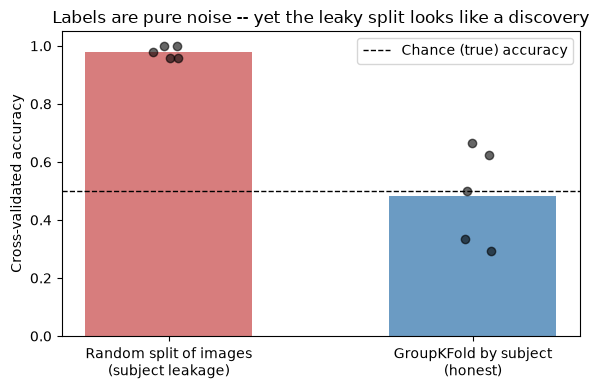

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
means = [acc_random.mean(), acc_grouped.mean()]
ax.bar([0, 1], means, width=0.55, color=["indianred", "steelblue"], alpha=0.8)
for i, vals in enumerate([acc_random, acc_grouped]):
    ax.plot(np.full_like(vals, i, dtype=float) + jitter_rng.uniform(-0.07, 0.07, vals.size),
            vals, "ko", alpha=0.6)
ax.axhline(0.5, color="k", ls="--", lw=1, label="Chance (true) accuracy")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Random split of images\n(subject leakage)",
                    "GroupKFold by subject\n(honest)"])
ax.set_ylabel("Cross-validated accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Labels are pure noise -- yet the leaky split looks like a discovery")
ax.legend()
plt.tight_layout()
plt.show()

The random split reaches accuracy far above chance **with zero true signal**: the classifier memorizes each subject's fingerprint from their training images and looks up the (random) label for that subject's test images. The grouped split, which forces prediction on *new people*, correctly reports chance performance.

The same principle covers all forms of linked observations — twins and family members belong in the same fold, adjacent time points from an autocorrelated series belong in the same fold (or separated by a temporal buffer), and any whole-dataset preprocessing (z-scoring, PCA, nuisance regression) must be fit on training data only.

## Part 3 — Effect-size shrinkage from training to independent test

Finally we give the model something real to find, and watch the *apparent* effect size shrink as the evaluation gets more honest. We simulate:

- a **training cohort** with a true linear brain–outcome relationship,
- an **independent test cohort** drawn from the same population, and
- a **shifted cohort** from a different site/population: the predictive pattern is only ~80% preserved, and the outcome scale is compressed (a different questionnaire calibration, say).

We fit ridge regression once on the training cohort, freeze it, and evaluate it four ways: in-sample, cross-validated within the training cohort, on the independent cohort, and on the shifted cohort. We report the prediction–outcome correlation *r*, its effect-size conversion $d = 2r/\sqrt{1-r^2}$, and **out-of-sample $R^2$** computed against the training-sample mean — the metric that keeps models honest about calibration.

In [6]:
rng = np.random.default_rng(7)
n_train, n_test, p = 100, 100, 30
w = rng.standard_normal(p)
w /= np.linalg.norm(w)                              # true predictive pattern

def simulate_cohort(n, pattern, signal=2.0, noise_sd=1.5, y_scale=1.0):
    X = rng.standard_normal((n, p))
    y = signal * (X @ pattern) + noise_sd * rng.standard_normal(n)
    return X, y_scale * y

# Training cohort and an independent cohort from the SAME population
X_tr, y_tr = simulate_cohort(n_train, w)
X_te, y_te = simulate_cohort(n_test, w)

# Shifted cohort: pattern only ~80% preserved; outcome scale compressed
u = rng.standard_normal(p); u /= np.linalg.norm(u)
w_shift = 0.8 * w + 0.6 * u
w_shift /= np.linalg.norm(w_shift)
X_sh, y_sh = simulate_cohort(n_test, w_shift, y_scale=0.4)

model = Ridge(alpha=10.0).fit(X_tr, y_tr)           # trained ONCE, then frozen

def r_to_d(r):
    return 2 * r / np.sqrt(1 - r**2)

def oos_r2(y_true, y_pred, ybar_train):
    return 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - ybar_train)**2)

ybar_train = y_tr.mean()
yhat_cv = cross_val_predict(Ridge(alpha=10.0), X_tr, y_tr,
                            cv=KFold(5, shuffle=True, random_state=0), n_jobs=1)

settings = {
    "In-sample (train on train)":   (y_tr, model.predict(X_tr)),
    "5-fold CV (within cohort)":    (y_tr, yhat_cv),
    "Independent cohort":           (y_te, model.predict(X_te)),
    "Shifted cohort (new site)":    (y_sh, model.predict(X_sh)),
}

rows = []
for name, (yt, yp) in settings.items():
    r = stats.pearsonr(yt, yp).statistic
    rows.append({"setting": name, "r": r, "Cohen's d": r_to_d(r),
                 "out-of-sample R2": oos_r2(yt, yp, ybar_train)})
results = pd.DataFrame(rows).set_index("setting").round(3)
print(results)

                                r  Cohen's d  out-of-sample R2
setting                                                       
In-sample (train on train)  0.877      3.651             0.764
5-fold CV (within cohort)   0.718      2.061             0.503
Independent cohort          0.775      2.452             0.590
Shifted cohort (new site)   0.552      1.324            -1.438


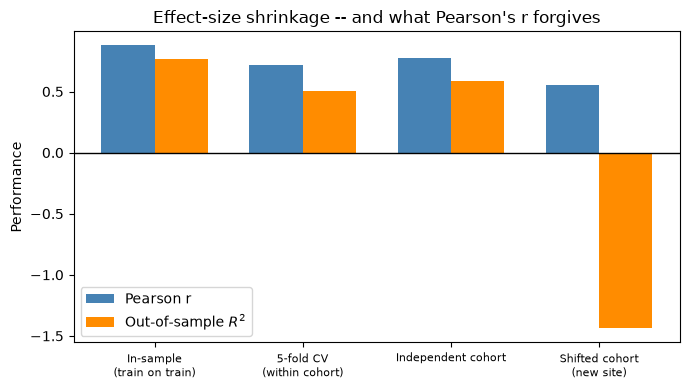

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
xpos = np.arange(len(results))
ax.bar(xpos - 0.18, results["r"], width=0.36, label="Pearson r", color="steelblue")
ax.bar(xpos + 0.18, results["out-of-sample R2"], width=0.36,
       label="Out-of-sample $R^2$", color="darkorange")
ax.axhline(0, color="k", lw=1)
ax.set_xticks(xpos)
ax.set_xticklabels([s.replace(" (", "\n(") for s in results.index], fontsize=8)
ax.set_ylabel("Performance")
ax.set_title("Effect-size shrinkage -- and what Pearson's r forgives")
ax.legend()
plt.tight_layout()
plt.show()

Three lessons from the table and figure:

1. **Shrinkage is the rule.** The in-sample fit is the most impressive number and the least meaningful one. Honest evaluations — cross-validation and the independent cohort — agree with each other and sit well below it. (Cross-validation is typically a touch *pessimistic* relative to a same-population independent test, because each fold trains on only 80% of the data — the fold-count tradeoff from the chapter.)
2. **Generalization degrades with distance.** In the shifted cohort, where the true pattern only partially overlaps the training population's, *r* drops further — mapping such drops across increasingly different samples is how a model's *boundary conditions* are established.
3. **Pearson's r hides miscalibration.** In the shifted cohort *r* remains respectably positive, but out-of-sample $R^2$ is strongly **negative**: the frozen model's predictions are spread on the training cohort's scale while the new cohort's outcomes are compressed, so its squared errors are *worse than just guessing the training mean*. Correlation silently re-fits offset and scale on the test data and forgives all of this; error-based metrics do not. Report RMSE and out-of-sample $R^2$, not *r* alone.

## Wrap-up

- Independence of training and test errors is the foundation of honest evaluation — engineer it through the split (whole subjects, whole families, whole runs together).
- Every data-dependent choice — preprocessing, feature selection, hyperparameters — belongs **inside** the cross-validation loop; nested CV is the standard way to keep selection and evaluation separate.
- Cross-validation estimates the performance of a *procedure*; the final model is re-trained on all data and its strongest test is a prospective one on independent samples.
- Prefer metrics without hidden flexibility: balanced accuracy and AUC for classification, RMSE and out-of-sample $R^2$ for regression, effect sizes ($d$, $d'$) for benchmarking.

The MATLAB lab mirrors these experiments with CANlab tools (`predict` with custom fold IDs, `roc_plot`, and a manual nested loop over PCR components).